# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## A Transformada de Fourier


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 

- [Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019]

- [Sinais e Sistemas Lineares, B. P. Lathi, ed. bookman, 2014]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [7]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

## 4. Análise de Sinais no Tempo Contínuo: A Transformada de Fourier



### 4.1 Representação de sinais não periódicos pela integral de Fourier

Aplicando um processo de limite, iremos mostrar que um sinal não periódico pode ser descrito pela soma contínua (integral) de exponenciais de duração infinita. Para representar um sinal não periódico $x(t)$, tal como o mostrado na Fig. 7.1a, por exponenciais de duração infinita, vamos construir um novo sinal periódico $x_{T_0}(t)$ formado pela repetição do sinal $x(t)$ em intervalos de $T_0$ segundos, como ilustrado na Fig. 7.1b. 


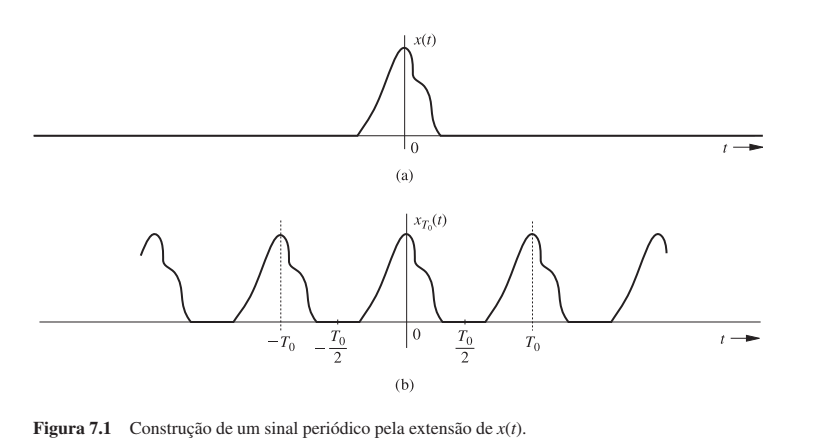



O período $T_0$ é feito grande o suficiente para evitar a sobreposição entre pulsos seguidos. O sinal periódico $x_{T_0}(t)$ pode ser representado por uma série exponencial de Fourier. Se fizermos $T_0 \rightarrow \infty$, os pulso no sinal periódico irão se repetir após um intervalo infinito, portanto,
$$
\lim _{T_0 \rightarrow \infty} x_{T_0}(t)=x(t)
$$
Dessa forma, a série de Fourier que representa $x_{T_0}(t)$ também irá representar $x(t)$ no limite de $T_0 \rightarrow \infty$. A série exponencial de Fourier para $x_{T_0}(t)$ é dada por
$$
x_{T_0}(t)=\sum_{n=-\infty}^{\infty} D_n e^{j n \omega_0 t}
$$
na qual
$$
D_n=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} x_{T_0}(t) e^{-j n \omega_0 t} d t
$$

$$
\omega_0=\frac{2 \pi}{T_0}
$$
Observe que integrar $x_{T_0}(t)$ em $\left(-T_0 / 2, T_0 / 2\right)$ é o mesmo que integrar $x(t)$ em $(-\infty, \infty)$. Portanto, podemos reescrever
$$
D_n=\frac{1}{T_0} \int_{-\infty}^{\infty} x(t) e^{-j n \omega_0 t} d t
$$
É interessante ver como a natureza do espectro muda quando $T_0$ aumenta. Para compreender esse fascinante comportamento, vamos definir $X(\omega)$, uma função contínua de $\omega$, por
<p style="color: blue">
$$
X(\omega)=\int_{-\infty}^{\infty} x(t) e^{-j \omega t} d t
$$</p>
Uma rápida análise das equações acima mostra que
$$
D_n=\frac{1}{T_0} X\left(n \omega_0\right)
$$


Isso significa que os coeficientes $D_n$ de Fourier são $1 / T_0$ vezes as amostras de $X(\omega)$ uniformemente espaçados em intervalos de $\omega_0$, como mostrado na Fig. 7.2a. 


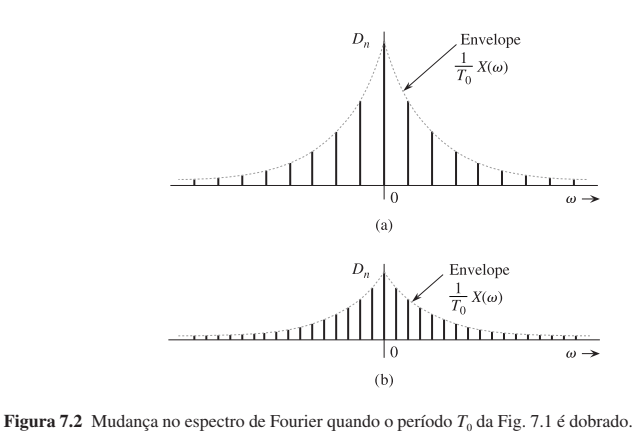

Portanto, $\left(1 / T_0\right) X(\omega)$ é o envelope para os coeficientes $D_n$. Iremos fazer, agora, $T_0 \rightarrow \infty$ dobrando o valor de $T_0$ repetidamente. Dobrando $T_0$ dividimos a frequência fundamental $\omega_0$, de tal forma que teremos agora duas vezes mais componentes (amostras) no espectro. 

Entretanto, dobrando $T_0$, o envelope $\left(1 / T_0\right) X(\omega)$ é dividido pela metade, como mostrado na Fig. 7.2b. Se continuarmos nesse processo de dobrar $T_0$ repetidamente, o espectro progressivamente se torna mais denso enquanto que sua magnitude se torna menor. 

Observe, entretanto, que a forma relativa do envelope permanece a mesma [proporcional a $X(\omega)$ na equação $X(\omega)=\int_{-\infty}^{\infty} x(t) e^{-j \omega t} d t$]. 

No limite, quando $T_0 \rightarrow \infty, \omega_0 \rightarrow 0$ e $D_n \rightarrow 0$. Esse resultado torna o espectro tão denso que as componentes espectrais ficam espaçadas com intervalos nulos (infinitesimais). 


A substituição adequada das equações acima resulta em
$$
x_{T_0}(t)=\sum_{n=-\infty}^{\infty} \frac{X\left(n \omega_0\right)}{T_0} e^{j n \omega_0 t}
$$
Quando $T_0 \rightarrow \infty, \omega_0$ se torna infinitesimal $\left(\omega_0 \rightarrow 0\right)$. Logo, podemos substituir $\omega_0$ por uma notação mais apropriada, $\Delta \omega$. Em termos dessa nova notação, temos
$$
\Delta \omega=\frac{2 \pi}{T_0}
$$
e
$$
x_{T_0}(t)=\sum_{n=-\infty}^{\infty}\left[\frac{X(n \Delta \omega) \Delta \omega}{2 \pi}\right] e^{(j n \Delta \omega) t}
$$
A última equação mostra que $x_{T_0}(t)$ pode ser descrito pela soma de exponenciais de duração exponencial de frequências $0, \pm \Delta \omega, \pm 2 \Delta \omega, \pm 3 \Delta \omega, \ldots$ (a série de Fourier). O total de componentes de frequência $n \Delta \omega$ é $[X(n \Delta \omega) \Delta \omega] / 2 \pi$. No limite, quando $T_0 \rightarrow \infty, \Delta \omega \rightarrow 0$ e $x_{T_o}(t) \rightarrow x(t)$. Portanto,

$$
\begin{aligned}
x(t) & =\lim _{T_0 \rightarrow \infty} x_{T_0}(t) \\
& =\lim _{\Delta \omega \rightarrow 0} \frac{1}{2 \pi} \sum_{n=-\infty}^{\infty} X(n \Delta \omega) e^{(j n \Delta \omega) t} \Delta \omega
\end{aligned}
$$
A soma do lado direito da equação acima pode ser entendida como a área sob a função $X(\omega) e^{j \omega t}$, como ilustrado na Fig. 7.3. 

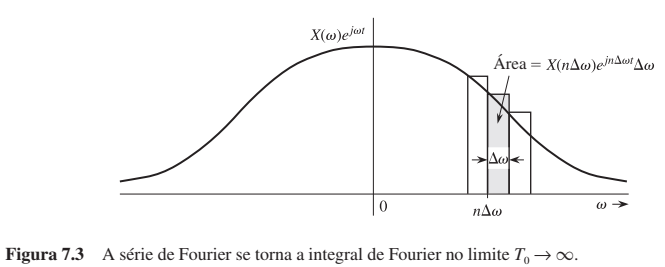

Assim sendo,
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$
A integral do lado direito é chamada de **integral de Fourier**. Neste momento, acabamos de obter sucesso na representação de um sinal não periódico $x(t)$ pela integral de Fourier (em vez da série de Fourier). 


Essa integral é basicamente a série de Fourier (no limite) com frequência fundamental $\Delta \omega \rightarrow 0$. O total da exponencial $e^{j n \Delta \omega t}$ é $X(n \Delta \omega) \Delta \omega / 2 \pi$. Portanto, a função $X(\omega)$ dada funciona como função espectral.

<p style="color: blue">Chamamos $X(\omega)$ de transformada de Fourier direta de $x(t)$ e $x(t)$ de transformada de Fourier inversa de $X(\omega)$. A mesma informação é contida na afirmação de que $x(t)$ e $X(\omega)$ são um par transformada de Fourier. Simbolicamente, essa afirmativa pode ser expressa por
$$
X(\omega)=\mathcal{F}[x(t)] \quad \text { e } \quad x(t)=\mathcal{F}^{-1}[X(\omega)]
$$
ou
$$
x(t) \Longleftrightarrow X(\omega)
$$
Recapitulando,
$$
x(t) \Longleftrightarrow X(\omega)
$$
e
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$ </p>

É útil manter em mente que a integral de Fourier ($x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega$) é da natureza da série de Fourier com frequência fundamental $\Delta \omega$ aproximando de zero. Portanto, a maior parte das discussões e propriedades da série de Fourier se aplicam à transformada de Fourier. A transformada $X(\omega)$ é a especificação no domínio da frequência de $x(t)$.

Podemos traçar o espectro de $X(\omega)$ em função de $\omega$. Como $X(\omega)$ é complexo, teremos tanto o espectro de amplitude quanto o de ângulo (ou fase)
$$
X(\omega)=|X(\omega)| e^{j \angle X(\omega)}
$$
na qual $|X(\omega)|$ é a amplitude e $\angle X(\omega)$ é o ângulo (ou fase) de $X(\omega)$. 

De acordo com definição,
$$
X(-\omega)=\int_{-\infty}^{\infty} x(t) e^{j \omega t} d t
$$
Tomando os conjugados dos dois lados dessa equação, teremos
$$
x^*(t) \Longleftrightarrow X^*(-\omega)
$$
Essa propriedade é conhecida como <p style="color: blue">Propriedade do conjugado.</p> 

Agora, se $x(t)$ for uma função real de $t$, então $x(t)=x^*(t)$ e da propriedade do conjugado, temos que
$$
X(-\omega)=X^*(\omega)
$$
Essa é a <p style="color: blue">Propriedade da simetria de conjugado da transformada de Fourier,</p> aplicável a $x(t)$ real. Portanto, para $x(t)$ real

$$
\begin{aligned}
|X(-\omega)| &= |X(\omega)|\\
\angle X(-\omega) &=- \angle X(\omega)
\end{aligned}
$$

``Portanto, para`` $x(t)$ ``real, o espectro de amplitude`` $|X(\omega)|$ ``é uma função par e o espectro de fase`` $\angle X(\omega)$ ``é uma função ímpar de`` $\omega$. Esses resultados também valem, para o espectro de Fourier de um sinal periódico.

**EXEMPLO 4.1**

Determine a transformada de Fourier de $e^{-a t} u(t)$.

Pela definição,
$$
X(\omega)=\int_{-\infty}^{\infty} e^{-a t} u(t) e^{-j \omega t} d t=\int_0^{\infty} e^{-(a+j \omega) t} d t=\left.\frac{-1}{a+j \omega} e^{-(a+j \omega) t}\right|_0 ^{\infty}
$$

Mas $\left|e^{-j \omega t}\right|=1$. Portanto, quando $t \rightarrow \infty, e^{-(a+j \omega) t}=e^{-a t} e^{-j \omega t}=\infty$ se $a<0$, mas será igual a 0 se $a>0$. Portanto,
$$
X(\omega)=\frac{1}{a+j \omega} \quad a>0
$$

Expressando $a+j \omega$ na forma polar como $\sqrt{a^2+\omega^2} e^{j \tan ^{-1}(\omega / a)}$, obtemos
$$
X(\omega)=\frac{1}{\sqrt{a^2+\omega^2}} e^{-j \tan ^{-1}(\omega / a)}
$$

Portanto,
$$
|X(\omega)|=\frac{1}{\sqrt{a^2+\omega^2}} \quad \text { e } \quad \angle X(\omega)=-\tan ^{-1}\left(\frac{\omega}{a}\right)
$$

O espectro de amplitude $|X(\omega)|$ e o espectro de fase $\angle X(\omega)$ estão mostrados na Fig. 7.4b. 

Observe que $|X(\omega)|$ é uma função par de $\omega$ e $\angle X(\omega)$ é uma função ímpar de $\omega$, como esperado.

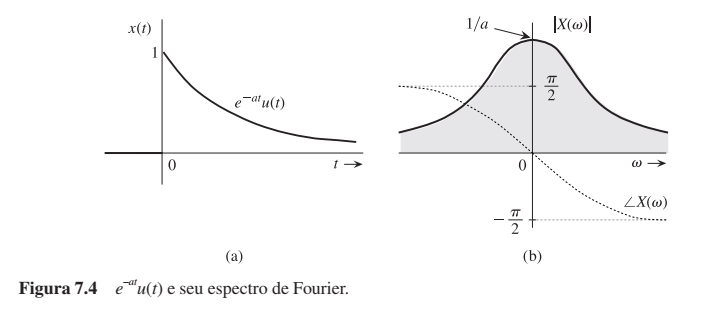

**EXISTÊNCIA DA TRANSFORMADA DE FOURIER**

No exemplo acima, observamos que quando $a<0$, a integral de Fourier de $e^{-a t} u(t)$ não converge. Logo, a transformada de Fourier de $e^{-a t} u(t)$ não existe se $a<0$ (exponencial crescente). Claramente, nem todos os sinais possuem sua transformada de Fourier.

Como a transformada de Fourier é obtida aqui como um caso limite da série de Fourier, ela possui as qualificações básicas da série de Fourier, tais como a igualdade na média, e as condições de convergência em uma forma adequadamente modificada também se aplicam à transformada de Fourier. 

Pode ser mostrado que se $x(t)$ possui energia finita, ou seja, se
$$
\int_{-\infty}^{\infty}|x(t)|^2 d t<\infty
$$
então a transformada de Fourier $X(\omega)$ é finita e converge para $x(t)$ na média. 

Isso significa que, se fizermos
$$
\hat{x}(t)=\lim _{W \rightarrow \infty} \frac{1}{2 \pi} \int_{-W}^W X(\omega) e^{j \omega t} d \omega
$$
então a equação $x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega$ implica
$$
\int_{-\infty}^{\infty}|x(t)-\hat{x}(t)|^2 d t=0
$$

Em outras palavras, $x(t)$ e sua integral de Fourier podem ser diferentes em alguns valores de $t$, sem, com isso, contradizer a equação $\int_{-\infty}^{\infty}|x(t)-\hat{x}(t)|^2 d t=0$. 

Iremos discutir, agora, um conjunto alternativo de critérios devido a Dirichlet para a convergência da transformada de Fourier.

Tal como na série de Fourier, se $x(t)$ satisfizer certas condições (condições de Dirichlet), garante-se a convergência de sua transformada de Fourier em todos os pontos nos quais $x(t)$ é contínuo. Além disso, nos pontos de descontinuidade, $x(t)$ converge para o valor médio entre os dois valores de $x(t)$ dos dois lados da descontinuidade. As condições de Dirichlet são mostradas a seguir:

1. $x(t)$ deve ser absolutamente integrável, ou seja,
$$
\int_{-\infty}^{\infty}|x(t)| d t<\infty
$$

Se essa condição for satisfeita, garantimos que a integral do lado direito da equação $x(t) \Longleftrightarrow X(\omega)$ possuirá um valor finito.

2. $x(t)$ deve possuir apenas um número finito de descontinuidades finitas dentro que qualquer intervalo finito.

3. $x(t)$ deve conter apenas um número finito de máximos ou mínimos dentro de qualquer intervalo finito.

``Reforçamos que, qualquer sinal que pode ser gerado na prática satisfaz as condições de Dirichlet e, portanto, possui sua transformada de Fourier.`` 

<p style="color: blue">Portanto, a existência física de um sinal é uma condição suficiente para a existência de sua transformada.</p>

**Linearidade da Transformada de Fourier**

A transformada de Fourier é linear, ou seja, se
$$
x_1(t) \Longleftrightarrow X_1(\omega) \quad \text { e } \quad x_2(t) \Longleftrightarrow X_2(\omega)
$$
então
$$
a_1 x_1(t)+a_2 x_2(t) \Longleftrightarrow a_1 X_1(\omega)+a_2 X_2(\omega)
$$

A prova é trivial e segue diretamente da equação $x(t) \Longleftrightarrow X(\omega)$. Esse resultado pode ser estendido para qualquer número finito de termos. Ele pode ser estendido para um número infinito de termos somente se as condições necessárias para alteração da ordem das operações de soma e integração forem satisfeitas.

#### Transformadas de Algumas Funções Úteis


Por conveniência, iremos apresentar uma notação compacta para funções de porta, triângulo e interpolação.

**FUNÇÃO DE PORTA UNITÁRIA**

Define-se a função de porta unitária ret $(x)$ como um pulso retangular de altura unitária e largura unitária, centrada na origem, como ilustrado na Fig. 7.7a:
$$
\operatorname{ret}(x)= \begin{cases}0 & |x|>\frac{1}{2} \\ \frac{1}{2} & |x|=\frac{1}{2} \\ 1 & |x|<\frac{1}{2}\end{cases}
$$


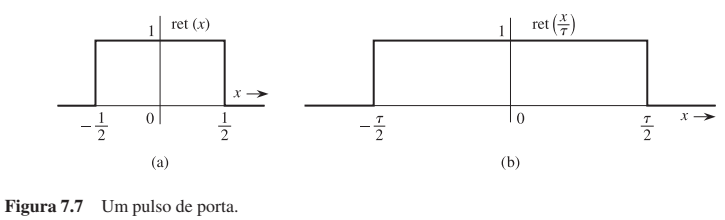

O pulso de porta da Fig. 7.7b é um pulso de porta unitário ret $(x)$ expandido por um fator $\tau$ ao longo do eixo horizontal e, portanto, pode ser descrito por ret $(x / \tau$ ). Observe que $\tau$, o denominador do argumento de ret $(x / \tau)$, indica a largura do pulso.

**FUNÇÃO TRIÂNGULO UNITÁRIO**

Define-se a função triângulo unitário $\Delta(x)$ como um pulso triangular de altura e largura unitárias, centrada na origem, como mostrado na Fig. 7.8a.
$$
\Delta(x)= \begin{cases}0 & |x| \geq \frac{1}{2} \\ 1-2|x| & |x|<\frac{1}{2}\end{cases}
$$

O pulso da Fig. 7.8 é $\Delta(x / \tau)$. Observe que, neste caso, tal como no pulso de porta, o denominador $\tau$ do argumento $\Delta(x / \tau)$ indica a largura do pulso.


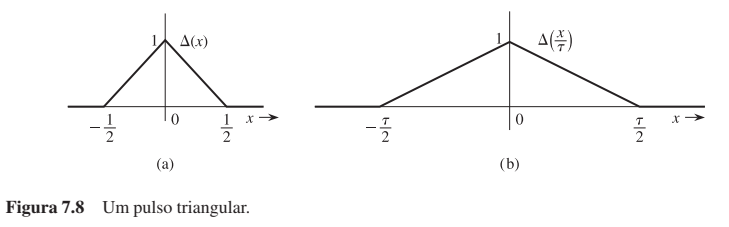


**FUNÇÃO INTERPOLAÇÃO** $\operatorname{sinc}(x)$


A função sen $x / x$ é a função "seno sobre argumento" representada por $sinc (x)$ Essa função possui um importante papel no processamento de sinais. Ela também é chamada de função de filtragem ou interpolação. Define-se
$$
\operatorname{sinc}(x)=\frac{\operatorname{sen} x}{x}
$$

A inspeção da equação acima mostra que:

1. sinc $(x)$ é uma função par de $x$.

2. $\operatorname{sinc}(x)=0$ quando sen $x=0$, exceto para $x=0$, quando ela aparentemente é indeterminada. Isso significa que $\operatorname{sinc}(x)=0$ para $x= \pm \pi, \pm 2 \pi, \pm 3 \pi, \ldots$

3. Usando a regra de L'Hôpital, obtemos $\operatorname{sinc}(0)=1$.

4. sinc ( $x$ ) é o produto de um sinal oscilatório sen $x$ (com período $2 \pi$ ) e uma função monotonicamente decrescente $1 / x$. Portanto, sinc $(x)$ exibe oscilações amortecidas com período $2 \pi$ e amplitude decrescente continuamente com $1 / x$.

A Fig. 7.9a mostra sinc $(x)$. Observe que sinc $(x)=0$ para valores de $x$ que são múltiplos inteiros positivos e negativos de $\pi$. A Fig. $7.9 \mathrm{~b}$ mostra $sinc(3 \omega / 7 )$. O argumento $3 \omega / 7=\pi$ quando $\omega=7 \pi / 3$. Portanto, o primeiro zero dessa função ocorre em $\omega=7 \pi / 3$.

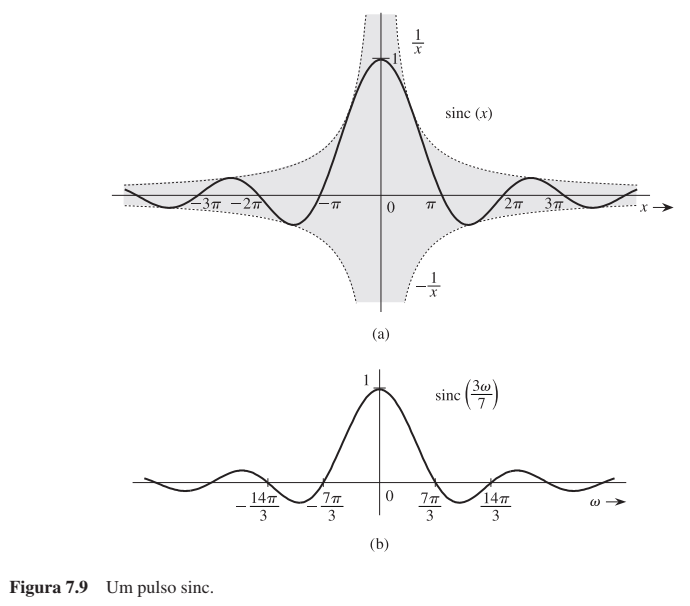

**EXEMPLO 4.2**

Obtenha a transformada de Fourier de $x(t)=\operatorname{ret}(t / \tau)$ (Fig. 7.10a).
$$
X(\omega)=\int_{-\infty}^{\infty} \operatorname{ret}\left(\frac{t}{\tau}\right) e^{-j \omega t} d t
$$


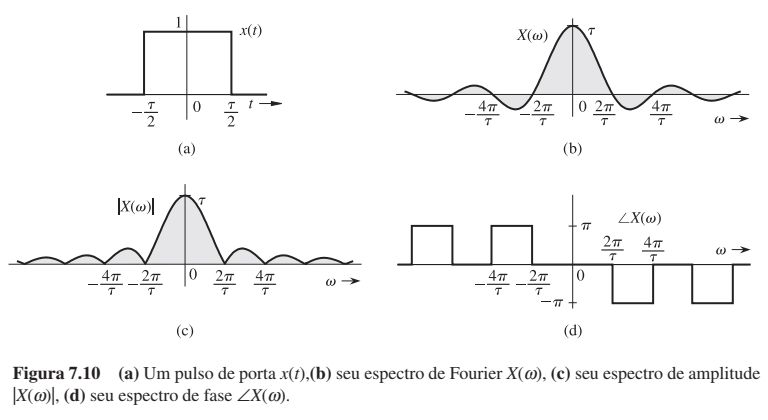

Como ret $(t / \tau)=1$ para $|t|<\tau / 2$ e zero para $|t|>\tau / 2$,
$$
\begin{aligned}
X(\omega) & =\int_{-\tau / 2}^{\tau / 2} e^{-j \omega t} d t \\
& =-\frac{1}{j \omega}\left(e^{-j \omega \tau / 2}-e^{j \omega \tau / 2}\right)=\frac{2 \operatorname{sen}\left(\frac{\omega \tau}{2}\right)}{\omega} \\
& =\tau \frac{\operatorname{sen}\left(\frac{\omega \tau}{2}\right)}{\left(\frac{\omega \tau}{2}\right)}=\tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)
\end{aligned}
$$

Portanto,
$$
\operatorname{ret}\left(\frac{t}{\tau}\right) \Longleftrightarrow \tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)
$$

Lembre-se de que sinc $(x)=0$ quando $x= \pm n \pi$. Logo, $\operatorname{sinc}(\omega \tau / 2)=0$ quando $\omega \tau / 2= \pm n \pi$, ou seja, quando $\omega= \pm 2 n \pi / \tau$, $(n=1,2,3, \ldots)$, como mostrado na Fig. 7.10b. A transformada de Fourier $X(\omega)$ mostrada na Fig. 7.10b possui valores positivos e negativos. Uma amplitude negativa pode ser considerada como uma amplitude positiva com fase de $-\pi$ ou $\pi$. Usamos essa observação para traçar o espectro de amplitude $|X(\omega)|$ $=|\operatorname{sinc}(\omega \tau / 2)|($ Fig 7.10c) e o espectro de fase $\angle X(\omega)$ (Fig. 7.10d). O espectro de fase, o qual deve ser uma função ímpar de $\omega$, pode ser desenhado por diversas outras formas porque um sinal negativo pode ser representado por uma fase de $\pm n \pi$, na qual $n$ é qualquer inteiro ímpar. Todas as representações são equivalentes.

**LARGURA DE FAIXA DE ret $(t / \tau)$**


O espectro de $X(\omega)$ da Fig. 7.10 possui um pico em $\omega=0$ e decai para altas frequências. Portanto, ret $(t / \tau)$ é um sinal passa baixa com a maior parte da energia do sinal em componentes de baixa frequência. Estritamente falando, como o espectro se estende de $0$ a $\infty$, a largura de faixa é $\infty$. Entretanto, grande parte do espectro é concentrado dentro do primeiro lóbulo ( $\operatorname{de} \omega=0 \mathrm{a} \omega=2 \pi / \tau$ ). Portanto, uma estimativa grosseira da largura de faixa de um pulso retangular com largura de $\tau$ segundos é $2 \pi / \tau \mathrm{rad} / \mathrm{s}$, ou $1 / \tau \mathrm{Hz}$. Note a relação recíproca entre a largura do pulso e sua largura de faixa. Iremos observar, posteriormente, que esse resultado geralmente é válido para todos os sinais.

**EXEMPLO 4.3**

Obtenha a transformada de Fourier par ao impulso unitário $\delta(t)$.


Usando a propriedade de amostragem do impulso, obtemos
$$
\mathcal{F}[\delta(t)]=\int_{-\infty}^{\infty} \delta(t) e^{-j \omega t} d t=1
$$
ou
$$
\delta(t) \Longleftrightarrow 1
$$

A Fig. 7.11 mostra $\delta(t)$ e seu espectro.

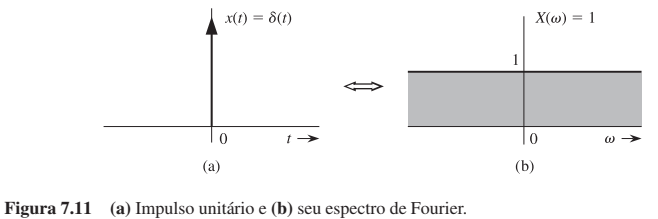

**EXEMPLO 4.4**

Obtenha a transformada de Fourier inversa de $\delta(\omega)$.

Com base na equação $x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega$ e na propriedade de amostragem da função impulso,
$$
\mathcal{F}^{-1}[\delta(\omega)]=\frac{1}{2 \pi} \int_{-\infty}^{\infty} \delta(\omega) e^{j \omega t} d \omega=\frac{1}{2 \pi}
$$

Portanto,
$$
\frac{1}{2 \pi} \Longleftrightarrow \delta(\omega)
$$

ou
$$
1 \Longleftrightarrow 2 \pi \delta(\omega)
$$

Esse resultado mostra que o espectro de um sinal constante $x(t)=1$ é um impulso $2 \pi \delta(\omega)$, como ilustrado na Fig. 7.12.

O resultado acima poderia ter sido antecipado com base qualitativa. Lembre-se de que a transformada de Fourier de $x(t)$ é a representação espectral de $x(t)$ em termos de componentes exponenciais de duração infinita na forma $e^{j \omega t}$. 

Para representar um sinal constante $x(t)=1$, precisamos de uma única exponencial de duração infinita $e^{j \omega t}$ com $ \omega=0$, resultando em um espectro em uma única frequência $\omega=0$. 

Outra forma de analisar essa situação é que $x(t)=1$ é um sinal cc, o qual possui uma única frequência, $\omega=0$ (cc).

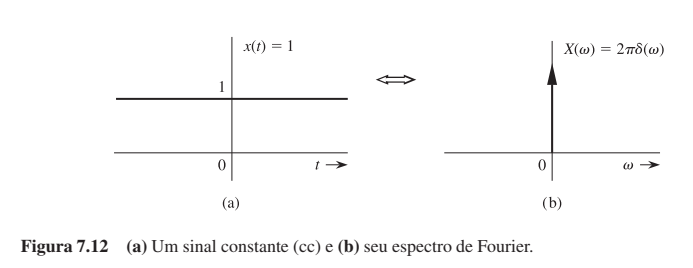

Se um impulso em $\omega=0$ é o espectro de um sinal cc, o que um impulso em $\omega=\omega_0$ representará? Iremos responder essa questão no próximo exemplo.

**EXEMPLO 4.5**

Obtenha a transformada de Fourier inversa de $\delta\left(\omega-\omega_0\right)$.

Usando a propriedade de amostragem da função impulso, obtemos
$$
\mathcal{F}^{-1}\left[\delta\left(\omega-\omega_0\right)\right]=\frac{1}{2 \pi} \int_{-\infty}^{\infty} \delta\left(\omega-\omega_0\right) e^{j \omega t} d \omega=\frac{1}{2 \pi} e^{j \omega_0 t}
$$

Portanto,
$$
\frac{1}{2 \pi} e^{j \omega_0 t} \Longleftrightarrow \delta\left(\omega-\omega_0\right)
$$
ou
$$
e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)
$$

Esse resultado mostra que o espectro de uma exponencial de duração infinita $e^{j \omega_0 t}$ é um único impulso em $\omega=\omega_0$. Podemos obter a mesma conclusão usando motivos qualitativos. Para representar a exponencial de duração infinita $e^{j \omega_0 t}$, precisamos de uma única exponencial de duração infinita $e^{j \omega t} \operatorname{com} \omega=$ $\omega_0$ Portanto, o espectro é constituído por uma única componente na frequência $\omega=\omega_0$.
A partir da equação $e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)$, temos que
$$
e^{-j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega+\omega_0\right)
$$

**EXEMPLO 4.6**

Obtenha a transformada de Fourier da senoide de duração infinita $\cos \omega_0 t$ (Fig. 7.13a).


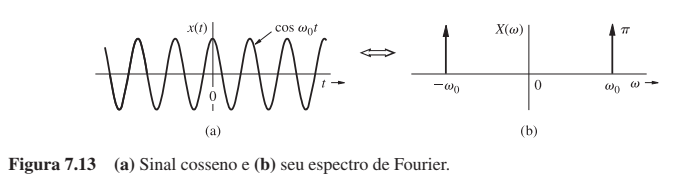

Lembre-se da fórmula de Euler,
$$
\cos \omega_0 t=\frac{1}{2}\left(e^{j \omega_0 t}+e^{-j \omega_0 t}\right)
$$

Adicionando as equações 

$$
e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)
$$
e

$$
e^{-j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega+\omega_0\right)
$$

e usando o resultado anterior, obtemos
$$
\cos \omega_0 t \Longleftrightarrow \pi\left[\delta\left(\omega+\omega_0\right)+\delta\left(\omega-\omega_0\right)\right]
$$

O espectro de $\cos \omega_0 t$ é constituído por dois impulsos em $\omega_0 \mathrm{e}-\omega_0$, como mostrado na Fig. 7.13b. O resultado também pode ser obtido usando motivos qualitativos. Uma senoide de duração infinita $\cos \omega_0 t$ pode ser sintetizada por duas exponenciais de duração infinita, $e^{j \omega_0 t}$ e $e^{-j \omega_0 t}$. Portanto, o espectro de Fourier é constituído por apenas duas componentes de frequência $\omega_0$ e $-\omega_0$.

**EXEMPLO 4.7 (Transformada de Fourier de um Sinal Periódico)**

Podemos utilizar a série de Fourier para descrever um sinal periódico pela soma de exponenciais na forma $e^{jn \omega_0 t}$, cuja transformada de Fourier é obtida na equação $e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)$. 

Logo, podemos obter facilmente a transformada de Fourier de um sinal periódico usando a propriedade da linearidade da equação $a_1 x_1(t)+a_2 x_2(t) \Longleftrightarrow a_1 X_1(\omega)+a_2 X_2(\omega)$.

A série de Fourier de um sinal periódico $x(t)$ com período $T_0$ é dada por
$$
x(t)=\sum_{n=-\infty}^{\infty} D_n e^{j n \omega_0 t} \quad \omega_0=\frac{2 \pi}{T_0}
$$

Obtendo a transformada de Fourier dos dois lado, temos
$$
X(\omega)=2 \pi \sum_{n=-\infty}^{\infty} D_n \delta\left(\omega-n \omega_0\right)
$$



**EXEMPLO 4.8**

A série de Fourier para um trem de impulso unitário $\delta_{T o}(t)$, mostrado na Fig. 7.14a, foi determinada no Exemplo 6.7. O coeficiente $D_n$ de Fourier para esse sinal, visto anteriormente, é a constante $D_n=1 / T_0$.


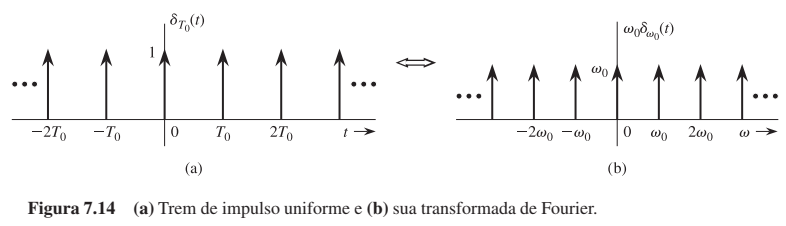

A partir da equação $X(\omega)=2 \pi \sum_{n=-\infty}^{\infty} D_n \delta\left(\omega-n \omega_0\right)$, a transformada de Fourier do trem de impulso unitário é
$$
\begin{aligned}
X(\omega) & =\frac{2 \pi}{T_0} \sum_{n=-\infty}^{\infty} \delta\left(\omega-n \omega_0\right) \quad \omega_0=\frac{2 \pi}{T_0} \\
& =\omega_0 \delta_{\omega_0}(\omega)
\end{aligned}
$$

O espectro correspondente é mostrado na Fig. 7.14b.

**EXEMPLO 4.9**

Obtenha a transformada de Fourier da função degrau unitário $u(t)$.

Se tentarmos obter a transformada de Fourier de $u(t)$ diretamente pela integração, teremos um resultado indeterminado porque
$$
U(\omega)=\int_{-\infty}^{\infty} u(t) e^{-j \omega t} d t=\int_0^{\infty} e^{-j \omega t} d t=\left.\frac{-1}{j \omega} e^{-j \omega t}\right|_0 ^{\infty}
$$

O limite superior de $e^{-j \omega t}$ quando $t \rightarrow \infty$ resulta em uma resposta indeterminada. Logo, abordamos esse problema considerando $u(t)$ como sendo a exponencial decrescente $e^{-a t} u(t)$ no limite quando $a \rightarrow 0$ (Fig.7.15). Logo,
$$
u(t)=\lim _{a \rightarrow 0} e^{-a t} u(t)
$$
e
$$
U(\omega)=\lim _{a \rightarrow 0} \mathcal{F}\left\{e^{-a t} u(t)\right\}=\lim _{a \rightarrow 0} \frac{1}{a+j \omega}
$$

Expressar o lado direito em termos de sua parte real e imaginária resulta em
$$
\begin{aligned}
U(\omega) & =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}-j \frac{\omega}{a^2+\omega^2}\right] \\
& =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}\right]+\frac{1}{j \omega}
\end{aligned}
$$


A função $a /\left(a^2+\omega^2\right)$ possui propriedades interessantes. Primeiro, a área sob essa função (Fig. 7.15b) é $\pi$, independente do valor de $a$ :
$$
\int_{-\infty}^{\infty} \frac{a}{a^2+\omega^2} d \omega=\left.\tan ^{-1} \frac{\omega}{a}\right|_{-\infty} ^{\infty}=\pi
$$

Segundo, quando $a \rightarrow 0$, esta função aproxima-se de zero para todo $\omega \neq 0$ e toda a sua área ( $\pi$ ) estará concentrada em um único ponto $\omega=0$. Claramente, quando $a \rightarrow 0$, essa função aproxima-se de um impulso com força $\pi .$ Portanto,
$$
U(\omega)=\pi \delta(\omega)+\frac{1}{j \omega}
$$

Note que $u(t)$ não é um "verdadeiro" sinal cc porque ele não é constante no intervalo de $-\infty$ a $\infty$. Para sintetizar um "verdadeiro" cc, seria necessária apenas uma exponencial de duração infinita em $\omega=0$ (impulso em $\omega=0$ ). O sinal $u(t)$ possui uma descontinuidade em $t=0$. É impossível sintetizar tal sinal com uma única exponencial de duração infinita $e^{j \omega t}$. Para sintetizar esse sinal usando exponenciais de duração infinita, precisamos, além de um impulso em $\omega=0$, de todas as componentes de frequência, como indicado pelo termo $1 / j \omega$ da equação $U(\omega)=\pi \delta(\omega)+\frac{1}{j \omega}$.

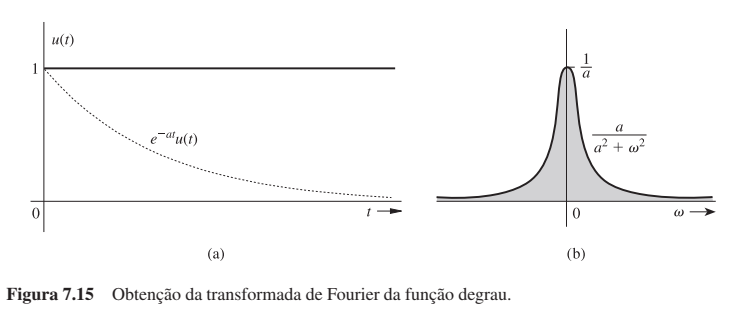

**EXEMPLO 4.10**

Obtenha a transformada de Fourier da função sinal sgn $(t)$, mostrada na Fig. 7.16.


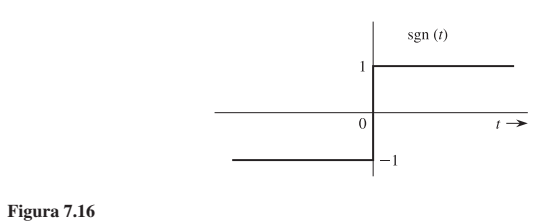

Observe que
$$
\operatorname{sgn}(t)+1=2 u(t) \Longrightarrow \operatorname{sgn}(t)=2 u(t)-1
$$

Usando os resultados das equações 

$$
1 \Longleftrightarrow 2 \pi \delta(\omega)
$$

e 
$$
U(\omega)=\pi \delta(\omega)+\frac{1}{j \omega}
$$
 e a propriedade da linearidade, obtemos
$$
\operatorname{sgn}(t) \Longleftrightarrow \frac{2}{j \omega}
$$

#### 4.3 Algumas Propriedades da Transformada de Fourier

Iremos estudar, agora, algumas propriedades importantes da transformada de Fourier e suas implicações e aplicações. Já encontramos duas importantes propriedades, linearidade e propriedade do conjugado.

Antes de começarmos em nosso estudo, iremos explicar um aspecto importante e permissivo da transformada de Fourier: a dualidade tempo-frequência.

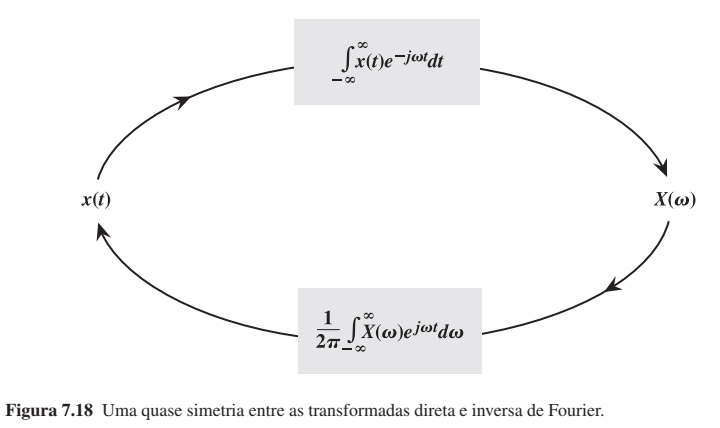

 - **DUALIDADE TEMPO-FREQUÊNCIA NAS OPERAÇÕES DE TRANSFORMAÇÃO**

As equações 
$$
\begin{gathered}
X(\omega)=\int_{-\infty}^{\infty} x(t) e^{-j \omega t} d t \\
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
\end{gathered}
$$

mostram um fato interessante: as operações de transformação direta e inversa são bastante similares. 

Essas operações, necessárias para ir de $x(t)$ para $X(\omega)$ e de $X(\omega)$ para $x(t)$, estão mostradas graficamente na Fig. 7.18. 

A equação da transformada inversa pode ser obtida da equação de transformada direta substituindo $x(t)$ por $X(\omega), t$ por $\omega$ e $\omega$ por $t$. De forma similar, podemos obter a transformada direta da inversa. Existem apenas duas pequenas diferenças nessas operações: o fator $2 \pi$ aparece apenas no operador inverso e o índice das exponenciais nas duas operações possuem sinais opostos. Caso contrário, as duas equações são duais uma da outra.

Essa observação possui consequências de longo alcance no estudo da transformada de Fourier. Ela é a base para a chamada ``dualidade de tempo e frequência.`` 

O princípio da dualidade pode ser comparado com uma fotografia e seu negativo. Uma fotografia pode ser obtida de seu negativo, e usando um procedimento idêntico, um negativo pode ser obtido da fotografia. Para qualquer resultado ou relação entre $x(t)$  e $X(\omega)$, existe um resultado ou relação dual obtido trocando os papeis de $x(t)$ e $X(\omega)$ no resultado original (juntamente com alguma pequena modificação em função do fator $2 \pi$  e da mudança de sinal). 

Por exemplo, a propriedade de deslocamento no tempo, a ser provada posteriormente, afirma que se $x(t) \Leftrightarrow X(\omega)$, então
$$
x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}
$$

A dual dessa propriedade (propriedade de deslocamento na frequência) afirma que
$$
x(t) e^{j \omega_0 t} \Longleftrightarrow X\left(\omega-\omega_0\right)
$$

Observe a inversão de papel entre tempo e frequência nessas duas equações (com a pequena diferença de mudança de sinal no índice da exponencial). O valor desse princípio está no fato de que sempre que obtivermos qualquer resultado, poderemos ter a certeza que ele possui um dual. Essa possibilidade viabiliza uma percepção valiosa sobre várias propriedades ou resultados escondidos no processamento de sinais.

As propriedades da transformada de Fourier são úteis não somente na obtenção das transformadas direta e inversa de várias funções, mas também na obtenção de vários resultados importantes no processamento de sinais. O leitor não deve esquecer de observar a sempre presente dualidade em nossas discussões.

 - **LINEARIDADE** 

A transformada de Fourier é linear, ou seja, se
$$
x_1(t) \Longleftrightarrow X_1(\omega) \quad \text { e } \quad x_2(t) \Longleftrightarrow X_2(\omega)
$$
então
$$
a_1 x_1(t)+a_2 x_2(t) \Longleftrightarrow a_1 X_1(\omega)+a_2 X_2(\omega)
$$


 - **CONJUGAÇÃO E SIMETRIA DE CONJUGADO**
 
A propriedade do conjugado afirma que se $x(t) \Leftrightarrow X(\omega)$, então
$$
x^*(t) \Longleftrightarrow X^*(-\omega)
$$

Desta propriedade, obtemos a propriedade da simetria de conjugado a qual afirma que se $x(t)$ é real, então,
$$
X(-\omega)=X^*(\omega)
$$


  - **DUALIDADE**
A propriedade da dualidade afirma que se
$$
x(t) \Longleftrightarrow X(\omega)
$$
então
$$
X(t) \Longleftrightarrow 2 \pi x(-\omega)
$$

**Prova.** Da equação 
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$
podemos escrever,
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(u) e^{j u t} d u
$$

Logo
$$
2 \pi x(-t)=\int_{-\infty}^{\infty} X(u) e^{-j u t} d u
$$

Trocando $t$ por $\omega$ obtemos 

$$
X(t) \Longleftrightarrow 2 \pi x(-\omega)
$$

**EXEMPLO 4.11**

Neste exemplo, iremos aplicar a propriedade da dualidade $[X(t) \Longleftrightarrow 2 \pi x(-\omega)]$ para o par da Fig. 7.19a.


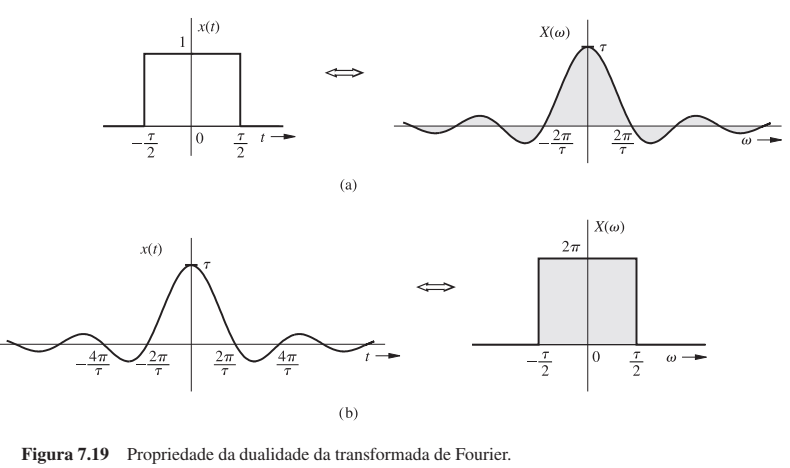

Da equação $\operatorname{ret}\left(\frac{t}{\tau}\right) \Longleftrightarrow \tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)$, temos que
$$
\underbrace{\operatorname{ret}\left(\frac{t}{\tau}\right)}_{x(t)} \Longleftrightarrow \underbrace{\tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)}_{X(\omega)}
$$

Além disso, $X(t)$ é o mesmo que $X(\omega)$ com $\omega$ substituído por $t$, e $x(-\omega)$ é o mesmo que $x(t)$ com $t$ substituído por $-\omega$. Portanto, a propriedade da dualidade resulta em
$$
\underbrace{\tau \operatorname{sinc}\left(\frac{\tau t}{2}\right)}_{X(t)} \Longleftrightarrow \underbrace{2 \pi \operatorname{ret}\left(\frac{-\omega}{\tau}\right)}_{2 \pi x(-\omega)}=2 \pi \operatorname{ret}\left(\frac{\omega}{\tau}\right)
$$

Na última equação, utilizamos o fato de que ret $(-x)=$ ret $(x)$ porque ret é uma função par. 

A Fig. 7.19b mostra esse par graficamente. Observe a troca nos papéis de $t$ e $\omega$ (com o pequeno ajuste do fator $2 \pi$ ). Esse resultado aparece como par 18 da Tabela $7.1(\operatorname{com} \tau / 2=W)$.

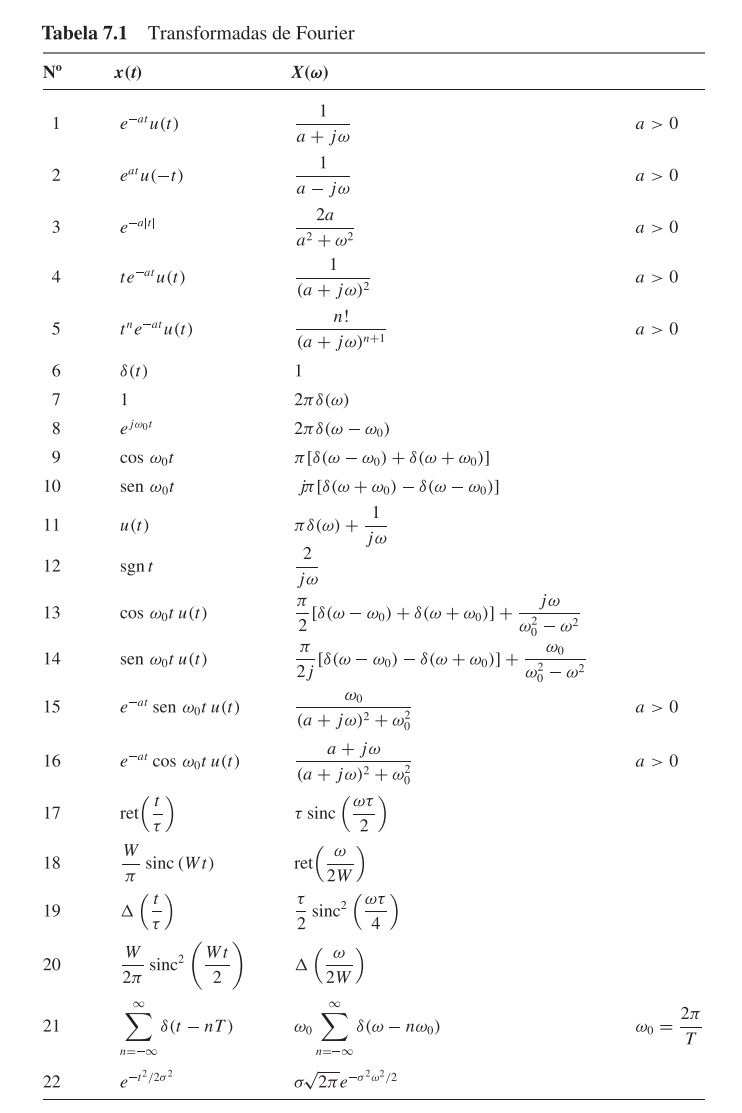

 - **PROPRIEDADE DE ESCALAMENTO**
 
Se
$$
x(t) \Longleftrightarrow X(\omega)
$$
então, para qualquer constante real $a$,
$$
x(a t) \Longleftrightarrow \frac{1}{|a|} X\left(\frac{\omega}{a}\right)
$$

**Prova.** Para uma constante real positiva $a$,
$$
\begin{aligned}
\mathcal{F}[x(a t)] & =\int_{-\infty}^{\infty} x(a t) e^{-j \omega t} d t \\
& =\frac{1}{a} \int_{-\infty}^{\infty} x(u) e^{(-j \omega / a) u} d u=\frac{1}{a} X\left(\frac{\omega}{a}\right)
\end{aligned}
$$

Similarmente, podemos demonstrar que se $a<0$,
$$
x(a t) \Longleftrightarrow \frac{-1}{a} X\left(\frac{\omega}{a}\right)
$$

Desta forma obtemos 

$$
x(a t) \Longleftrightarrow \frac{1}{|a|} X\left(\frac{\omega}{a}\right)
$$

**Significado da Propriedade de Escalamento**

A função $x(a t)$ representa a função $x(t)$ comprimida no tempo pelo fator $a$. Similarmente, a função $X(\omega / a)$ representa a função $X(\omega)$ expandida na frequência pelo mesmo fator $a$. 

A propriedade de escalamento afirma que a compressão no tempo de um sinal resulta na expansão do seu espectro e a expansão no tempo de um sinal resulta na compressão de seu espectro. Intuitivamente, a compressão no tempo pelo fator $a$ significa que o sinal está variando mais rápido, pelo fator a. 

Para sintetizar esse sinal, as frequências de suas componentes senoidais devem ser aumentadas por um fator $a$, implicando a expansão do seu espectro pelo fator $a$. Similarmente, um sinal expandido no tempo varia mais lentamente, logo as frequências de suas componentes são diminuídas, implicando a compressão de seu espectro de frequência. 

Por exemplo, o sinal $\cos 2 \omega_0 t$ é o mesmo que o sinal $\cos \omega_0 t$ comprimido no tempo por um fator 2. Obviamente, o espectro do primeiro (impulso em $\pm 2 \omega_0$ ) é uma versão expandida do espectro do último (impulso em $\pm \omega_0$ ). O efeito desse escalamento está demonstrado na Fig. 7.20.



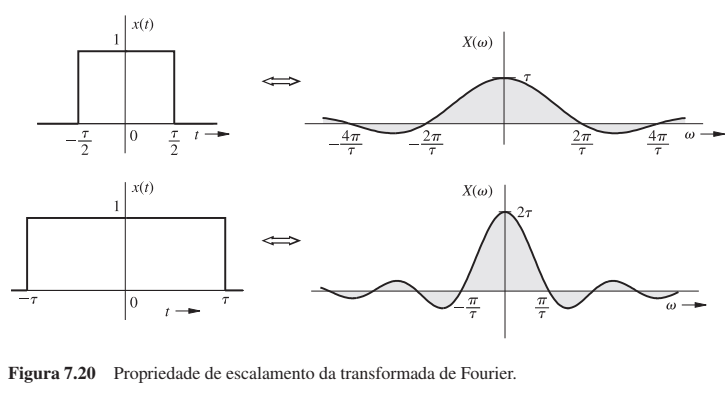


 **RECIPROCIDADE DA DURAÇÃO DO SINAL E SUA LARGURA DE FAIXA**
 
A propriedade de escalamento implica que se $x(t)$ for alargado, seu espectro é estreitado, e vice-versa. Dobrando a duração do sinal, dividimos pela metade sua largura de faixa, e vice-versa. Isso sugere que a largura de faixa de um sinal é inversamente proporcional à duração ou largura (em segundos) do sinal. Já verificamos esse fato para o pulso de porta, quando obtivemos que a largura de faixa de um pulso de porta com largura $\tau$ segundos é $1 / \tau$ Hz. Mais discussões sobre esse interessante tópico podem ser encontradas na literatura. 


 - **INVERSÃO DO TEMPO E FREQUÊNCIA**
 
Fazendo $a=-1$ na $x(a t) \Longleftrightarrow \frac{1}{|a|} X\left(\frac{\omega}{a}\right)$, obtemos a propriedade de inversão do tempo e frequência:
$$
x(-t) \Longleftrightarrow X(-\omega)
$$

**EXEMPLO 4.12**

Obtenha as transformadas de Fourier de $e^{a t} u(-t)$ e $e^{-a|t|}$.

A aplicação da equação $x(-t) \Longleftrightarrow X(-\omega)$ ao par 1 (Tabela 7.1) resulta em
$$
e^{a t} u(-t) \Longleftrightarrow \frac{1}{a-j \omega} \quad a>0
$$

Além disso,
$$
e^{-a|t|}=e^{-a t} u(t)+e^{a t} u(-t)
$$

Portanto,
$$
e^{-a|t|} \Longleftrightarrow \frac{1}{a+j \omega}+\frac{1}{a-j \omega}=\frac{2 a}{a^2+\omega^2} \quad a>0
$$

O sinal $e^{-a|| t \mid}$ e seu espectro estão mostrados na Fig. 7.21.

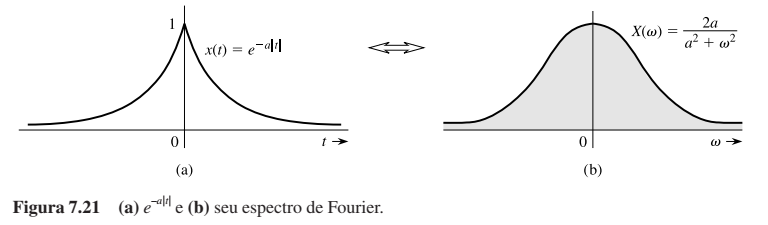

 - **Propriedade de Deslocamento no Tempo**

Se
$$
x(t) \Longleftrightarrow X(\omega)
$$
então
$$
x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}
$$

**Prova.** Pela definição,
$$
\mathcal{F}\left[x\left(t-t_0\right)\right]=\int_{-\infty}^{\infty} x\left(t-t_0\right) e^{-j \omega t} d t
$$

Fazendo $t-t_0=u$, temos
$$
\begin{aligned}
\mathcal{F}\left[x\left(t-t_0\right)\right] & =\int_{-\infty}^{\infty} x(u) e^{-j \omega\left(u+t_0\right)} d u \\
& =e^{-j \omega t_0} \int_{-\infty}^{\infty} x(u) e^{-j \omega u} d u=X(\omega) e^{-j \omega t_0}
\end{aligned}
$$

Esse resultado mostra que atrasar um sinal por $t_0$ segundos não altera seu espectro de amplitude. O espectro de fase, entretanto, é alterado por $-\omega t_0$.

**EXPLICAÇÃO FÍSICA DA FASE LINEAR**

O atraso de tempo em um sinal causa um deslocamento de fase em seu espectro. Esse resultado também pode ser obtido usando razões heurísticas. Imagine $x(t)$ sendo sintetizado por suas componentes de Fourier, as quais são senóides de certa amplitude e fase. O sinal atrasado $x\left(t-t_0\right)$ pode ser sintetizado pelas mesmas componentes senoidais, cada uma atrasada por $t_0$ segundos. As amplitudes das componentes permanecem inalteradas. Portanto, o espectro de amplitude de $x\left(t-t_0\right)$ é idêntico ao de $x(t)$. $\mathrm{O}$ atraso de tempo de $t_0$ em cada senóide, entretanto, altera a fase de cada componente. Agora, a senóide $\cos \omega t$ atrasada por $t_0$ é dada por
$$
\cos \omega\left(t-t_0\right)=\cos \left(\omega t-\omega t_0\right)
$$

Portanto, um atraso de tempo de $t_0$ em uma senóide de frequência $\omega$ é manifestado como um atraso de fase de $\omega t_0$. Isso é uma função linear de $\omega$, significando que as componentes de alta frequência devem resultar em um deslocamento de fase proporcionalmente maior para obter o mesmo atraso de tempo. Esse efeito é mostrado na Fig. 7.22 com duas senóides, a frequência da senóide inferior é o dobro da senóide superior. O mesmo atraso de tempo $t_0$ resulta em um deslocamento de fase de $\pi / 2$ na senóide superior e em um deslocamento de fase de $\pi$ na senóide inferior. Isso comprova o fato de que para obter um mesmo atraso de tempo, senóides de mais alta freqüência devem sofrer um deslocamento de fase proporcionalmente maior. O princípio do deslocamento de fase linear é muito importante e iremos encontrá-lo novamente em transmissão de sinal sem distorção e aplicações de filtragem.


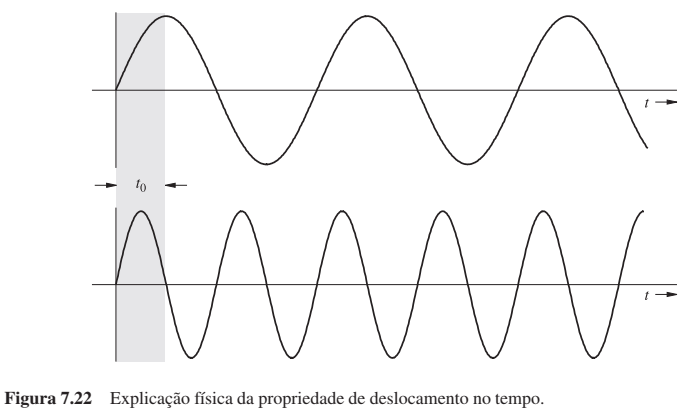

**EXEMPLO 4.13**

Obtenha a transformada de Fourier de $e^{-a\left|t-t_o\right|}$.

Essa função, mostrada na Fig. 7.23a, é uma versão deslocada no tempo de $e^{-a|| t \mid}$ (mostrada na Fig. 7.21a). A partir das equações 
$$
e^{-a|t|} \Longleftrightarrow \frac{1}{a+j \omega}+\frac{1}{a-j \omega}=\frac{2 a}{a^2+\omega^2} \quad a>0
$$
e 

$$
x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0},
$$
temos
$$
e^{-a\left|t-t_0\right|} \Longleftrightarrow \frac{2 a}{a^2+\omega^2} e^{-j \omega t_0}
$$

O espectro de $e^{-a\left|t-t_o\right|}$ (Fig. 7.23b) é o mesmo de $e^{-a|t|}$ (Fig. 7.21b), exceto pelo deslocamento de fase adicional de $-\omega t_0$.

Observe que o deslocamento de tempo $t_0$ resulta em um espectro de fase linear $-\omega t_0$. Este exemplo demonstra claramente o efeito do deslocamento no tempo.


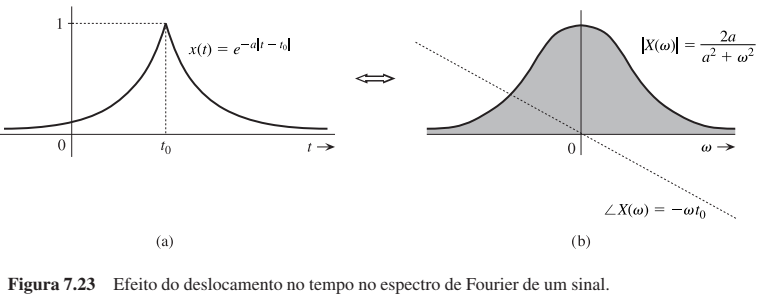

**EXEMPLO 4.14**

Obtenha a transformada de Fourier do pulso de porta $x(t)$ ilustrado na Fig. 7.24a.


O pulso $x(t)$ é o pulso de porta ret $(t / \tau)$ da Fig. 7.10 atrasado por $3 \tau / 4$ segundos. Logo, de acordo com a equação $x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}$, sua transformada de Fourier é a transformada de Fourier de ret $(t / \tau)$ multiplicada por $e^{-j \omega(3 t / 4)}$. Portanto,
$$
X(\omega)=\tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right) e^{-j \omega(3 \tau / 4)}
$$

O espectro de amplitude $|X(\omega)|$ (mostrado na Fig. 7.24b) do pulso é o mesmo do indicado na Fig. 7.10c. Mas o espectro de fase possui um termo linear adicionado igual a $-3 \omega \tau / 4$. Logo, o espectro de fase de $x(t)$ (Fig. 7.24a) é idêntico ao da Fig. 7.10 mais um termo linear $-3 \omega \tau / 4$, como mostrado na Fig. 7.24c.



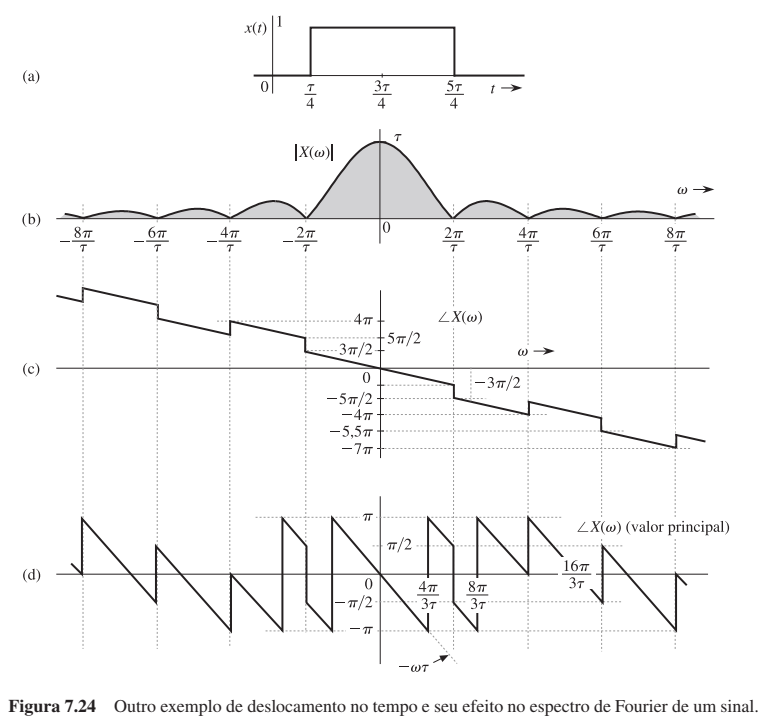

**ESPECTRO DE FASE USANDO VALORES PRINCIPAIS**
 
Existe uma forma alternativa para a representação de $\angle X(\omega)$. O ângulo de fase calculado por uma calculadora ou usando uma sub-rotina em um computador geralmente é o valor principal (valor módulo $2 \pi$ ) do ângulo de fase, o qual sempre está na faixa de $-\pi$ a $\pi$. Por exemplo, o valor principal do ângulo $3 \pi / 2$ é $-\pi / 2$, e assim por diante. O valor principal difere do valor real por $\pm 2 \pi$ (e seus múltiplos inteiros) de forma que garanta que o valor principal permaneça entre $-\pi$ a $\pi$. Portanto, o valor principal irá mostrar descontinuidades de $\pm 2 \pi$ sempre que a fase real cruzar $\pm \pi$. O gráfico de fase da Fig. 7.24 c é redesenhado na Fig. 7.24d usando apenas os valores principais da fase. Esse padrão de fase, o qual apresenta descontinuidades de fase de magnitudes $2 \pi$ e $\pi$, se torna repetitivo a intervalos de $\omega=8 \pi / \tau$.

 - **PROPRIEDADE DE DESLOCAMENTO NA FREQUÊNCIA**
 
Se
$$
x(t) \Longleftrightarrow X(\omega)
$$
então,
$$
x(t) e^{j \omega_0 t} \Longleftrightarrow X\left(\omega-\omega_0\right)
$$

**Prova.** Pela definição
$$
\mathcal{F}\left[x(t) e^{j \omega_0 t}\right]=\int_{-\infty}^{\infty} x(t) e^{j \omega_0 t} e^{-j \omega t} d t=\int_{-\infty}^{\infty} x(t) e^{-j\left(\omega-\omega_0\right) t} d t=X\left(\omega-\omega_0\right)
$$

De acordo com essa propriedade, a multiplicação de um sinal por um fator $e^{j \omega t t}$ desloca o espectro do sinal por $\omega=\omega_0$. Note a dualidade entre as propriedades de deslocamento no tempo e deslocamento na frequência.
Trocando $\omega_0$ por $-\omega_0$ na equação $x(t) e^{j \omega_0 t} \Longleftrightarrow X\left(\omega-\omega_0\right)$ resulta em
$$x(t) e^{-j \omega_0 t} \Longleftrightarrow X\left(\omega+\omega_0\right)$$

Como $e^{j \omega_0 t}$ não é uma função real que pode ser gerada, o deslocamento na frequência na prática é obtido multiplicando $x(t)$ por uma senóide. Observe que
$$
x(t) \cos \omega_0 t=\frac{1}{2}\left[x(t) e^{j \omega_0 t}+x(t) e^{-j \omega_0 t}\right]
$$

A partir das equações 
$$
x(t) e^{j \omega_0 t} \Longleftrightarrow X\left(\omega-\omega_0\right),
$$
e
$$
x(t) e^{-j \omega_0 t} \Longleftrightarrow X\left(\omega+\omega_0\right),
$$
temos
$$
x(t) \cos \omega_0 t \Longleftrightarrow \frac{1}{2}\left[X\left(\omega-\omega_0\right)+X\left(\omega+\omega_0\right)\right]
$$

Esse resultado mostra que a multiplicação de um sinal $x(t)$ por uma senóide de frequência $\omega_0$ desloca o espectro $X(\omega)$ por $\pm \omega_0$, como mostrado na Fig. 7.25.

A multiplicação de uma senóide por $\cos \omega_0 t$ por $x(t)$ resulta em uma senóide modulada em amplitude. Esse tipo de modulação é chamado de modulação em amplitude. A senóide $\cos \omega_0 t$ é chamada de portadora, o sinal $x(t)$ é o sinal modulante e o $\operatorname{sinal} x(t) \cos \omega_0 t$ é o sinal modulado. 

$$
x(t) \cos \omega_0 t= \begin{cases}x(t) & \text { quando } \cos \omega_0 t=1 \\ -x(t) & \text { quando } \cos \omega_0 t=-1\end{cases}
$$

Portanto, $x(t) \cos \omega_0 t$ toca $x(t)$ quando a senóide $\cos \omega_0 t$ está em seu pico positivo e toca $-x(t)$ quando $\cos \omega_0 t$ está em seu pico negativo. Isso significa que $x(t)$ e $-x(t)$ funcionam como envelopes para o sinal $x(t) \cos \omega_0 t$ (veja a Fig. 7.25). O sinal $-x(t)$ é uma imagem espelhada de $x(t)$ com relação ao eixo horizontal. A Fig. 7.25 mostra os sinais $x(t)$ e $x(t) \cos \omega_0 t$ e seus espectros.

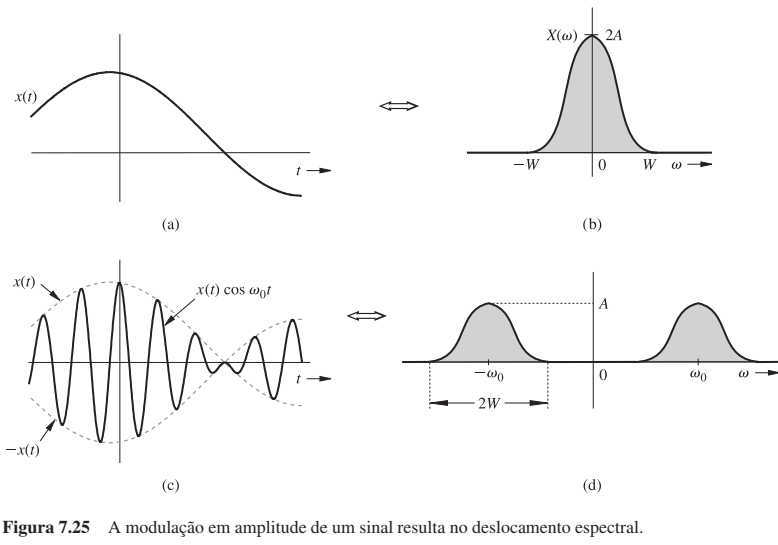

**EXEMPLO 7.15**

Determine e trace a transformada de Fourier do sinal modulado $x(t) \cos 10 t$ no qual $x(t)$ é um pulso de porta ret $(t / 4)$ como ilustrado na Fig. 7.26a.

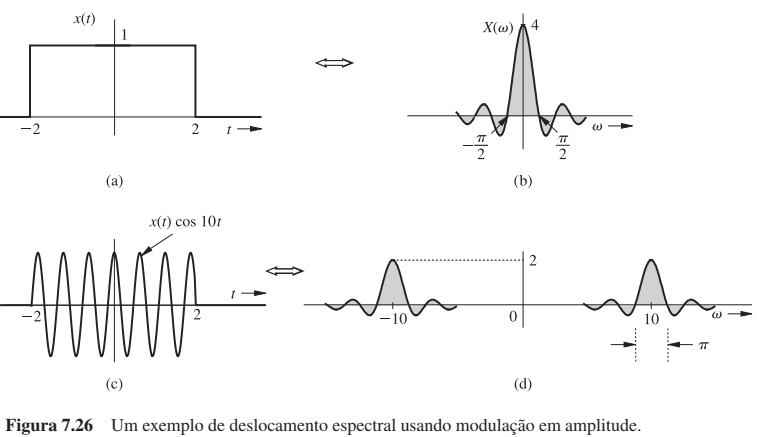


A partir do par 17 (Tabela 7.1), temos que ret $(t / 4) \Leftrightarrow 4 \operatorname{sinc}(2 \omega)$, o que é mostrado na Fig. 7.26b. 

A partir da equação
$$
x(t) \cos \omega_0 t \Longleftrightarrow \frac{1}{2}\left[X\left(\omega-\omega_0\right)+X\left(\omega+\omega_0\right)\right],
$$
obtemos
$$
x(t) \cos 10 t \Longleftrightarrow \frac{1}{2}[X(\omega+10)+X(\omega-10)].
$$

Neste caso, $X(\omega)=4 \operatorname{sinc}(2 \omega)$. Portanto,
$$
x(t) \cos 10 t \Longleftrightarrow 2 \operatorname{sinc}[2(\omega+10)]+2 \operatorname{sinc}[2(\omega-10)]
$$

O espectro de $x(t) \cos 10 t$ é obtido deslocando $X(\omega)$ da Fig. 7.26b para a esquerda por 10 e para a direita por 10 e, então, multiplicando-o por 0,5 , como mostrado na Fig. $7.26 \mathrm{~d}$.

 - **Convolução**
 
A propriedade de convolução no tempo e sua dual, a propriedade de convolução na frequência, afirma que se
$$
x_1(t) \Longleftrightarrow X_1(\omega) \quad \text { e } \quad x_2(t) \Longleftrightarrow X_2(\omega)
$$
então
$$
x_1(t) * x_2(t) \Longleftrightarrow X_1(\omega) X_2(\omega) \quad \text { (convolução no tempo) }
$$
e
$$
x_1(t) x_2(t) \Longleftrightarrow \frac{1}{2 \pi} X_1(\omega) * X_2(\omega) \quad \text { (convolução na frequência) }
$$

**Prova**. Pela definição
$$
\begin{aligned}
\mathcal{F}\left|x_1(t) * x_2(t)\right| & =\int_{-\infty}^{\infty} e^{-j \omega t}\left[\int_{-\infty}^{\infty} x_1(\tau) x_2(t-\tau) d \tau\right] d t \\
& =\int_{-\infty}^{\infty} x_1(\tau)\left[\int_{-\infty}^{\infty} e^{-j \omega t} x_2(t-\tau) d t\right] d \tau
\end{aligned}
$$

A integral interna é a transformada de Fourier de $x_2(t-\tau)$, dada por [propriedade de deslocamento no tempo da equação $x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}$] $X_2(\omega) e^{-j \omega \tau}$. Logo,


$$
\mathcal{F}\left[x_1(t) * x_2(t)\right]=\int_{-\infty}^{\infty} x_1(\tau) e^{-j \omega \tau} X_2(\omega) d \tau=X_2(\omega) \int_{-\infty}^{\infty} x_1(\tau) e^{-j \omega \tau} d \tau=X_1(\omega) X_2(\omega).
$$
Seja $H(\omega)$ a transformada de Fourier da resposta ao impulso unitário $h(t)$, ou seja,
$$
h(t) \Longleftrightarrow H(\omega)
$$

A aplicação da propriedade de convolução no tempo a $y(t)=x(t) * h(t)$ resulta em (assumindo que tanto $x(t)$ quanto $h(t)$ possuem suas transformadas de Fourier)
$$
Y(\omega)=X(\omega) H(\omega)
$$

A propriedade de convolução na frequência pode ser provada exatamente da mesma forma simplesmente pela alteração dos papéis de $x(t)$ e $X(\omega)$.

**EXEMPLO 4.16**

Utilize a propriedade de convolução no tempo para mostrar que se
$$
x(t) \Longleftrightarrow X(\omega)
$$
então
$$
\int_{-\infty}^t x(\tau) d \tau \Longleftrightarrow \frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega)
$$

Como
$$
u(t-\tau)= \begin{cases}1 & \tau \leq t \\ 0 & \tau>t\end{cases}
$$

temos que
$$
x(t) * u(t)=\int_{-\infty}^{\infty} x(\tau) u(t-\tau) d \tau=\int_{-\infty}^t x(\tau) d \tau
$$

Agora, da propriedade de convolução no tempo, temos que
$$
\begin{aligned}
x(t) * u(t) & =\int_{-\infty}^t x(\tau) d \tau \Longleftrightarrow X(\omega)\left[\frac{1}{j \omega}+\pi \delta(\omega)\right] \\
& =\frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega)
\end{aligned}.
$$


 - **DIFERENCIAÇÃO E INTEGRAÇÃO NO TEMPO**
 
 Se
$$
x(t) \Longleftrightarrow X(\omega)
$$
então
$$
\frac{d x}{d t} \Longleftrightarrow j \omega X(\omega) \quad \text { (diferenciação no tempo) }
$$
e
$$
\int_{-\infty}^t x(\tau) d \tau \Longleftrightarrow \frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega) \quad \text { (integração no tempo) }
$$

**Prova.** A diferenciação dos dois lados da equação 

$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$
resulta em
$$
\frac{d x}{d t}=\frac{1}{2 \pi} \int_{-\infty}^{\infty} j \omega X(\omega) e^{j \omega t} d \omega
$$

Esse resultado mostra que

$$
\frac{d x}{d t} \Longleftrightarrow j \omega X(\omega)
$$

A aplicação repetida dessa propriedade leva a
$$
\frac{d^n x}{d t^n} \Longleftrightarrow(j \omega)^n X(\omega)
$$

A propriedade de integração no tempo já foi provada no Exemplo 4.16. 

As propriedades da transformada de Fourier estão resumidas na Tabela 7.2.

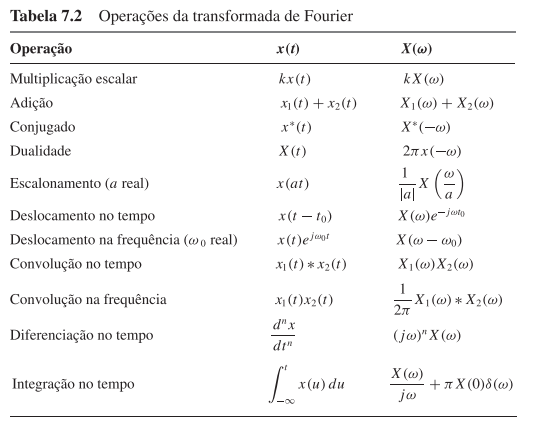

**EXEMPLO 7.17**

Utilize a propriedade de diferenciação no tempo para obter a transformada de Fourier do pulso triangular $\Delta(t / \tau)$ apresentado na Fig. 7.27a.

Para determinarmos a transformada de Fourier desse pulso, iremos diferenciar o pulso sucessivamente, como mostrado na Fig. 7.27b e 7.27c. Como $d x / d t$ é uma constante, sua derivada, $d^2 x / d t^2$, é zero. Mas $d x / d t$ possui descontinuidades com um salto positivo de $2 / \tau$ em $ t= \pm \tau / 2$ e um salto negativo de $4 / \tau$ em $t=0$. Lembre que a derivada de um sinal em um salto de descontinuidade é um impulso naquele ponto de força igual ao total do salto. Logo, $d^2 x / d t^2$, a derivada de $d x / d t$, é constituída por uma sequência de impulsos, como mostrado na Fig. 7.27c, ou seja,
$$
\frac{d^2 x}{d t^2}=\frac{2}{\tau}\left[\delta\left(t+\frac{\tau}{2}\right)-2 \delta(t)+\delta\left(t-\frac{\tau}{2}\right)\right]
$$

Usando a propriedade de diferenciação no tempo,
$$
\frac{d^2 x}{d t^2} \Longleftrightarrow(j \omega)^2 X(\omega)=-\omega^2 X(\omega)
$$

Além disso, da propriedade de deslocamento no tempo 
$$
\delta\left(t-t_0\right) \Longleftrightarrow e^{-j \omega t_0}
$$

Obtendo a transformada de Fourier da equação $\frac{d^2 x}{d t^2}=\frac{2}{\tau}\left[\delta\left(t+\frac{\tau}{2}\right)-2 \delta(t)+\delta\left(t-\frac{\tau}{2}\right)\right]$ e usando os resultados das equações $\frac{d^2 x}{d t^2} \Longleftrightarrow(j \omega)^2 X(\omega)=-\omega^2 X(\omega)$ e $\delta\left(t-t_0\right) \Longleftrightarrow e^{-j \omega t_0}$, obtemos
$$
-\omega^2 X(\omega)=\frac{2}{\tau}\left[e^{j(\omega \tau / 2)}-2+e^{-j(\omega \tau / 2)}\right]=\frac{4}{\tau}\left(\cos \frac{\omega \tau}{2}-1\right)=-\frac{8}{\tau} \operatorname{sen}^2\left(\frac{\omega \tau}{4}\right)
$$
e
$$
X(\omega)=\frac{8}{\omega^2 \tau} \operatorname{sen}^2\left(\frac{\omega \tau}{4}\right)=\frac{\tau}{2}\left[\frac{\operatorname{sen}\left(\frac{\omega \tau}{4}\right)}{\frac{\omega \tau}{4}}\right]^2=\frac{\tau}{2} \operatorname{sinc}^2\left(\frac{\omega \tau}{4}\right)
$$

O espectro $X(\omega)$ é mostrado na Fig. 7.27d. Esse procedimento de obtenção da transformada de Fourier pode ser aplicado a qualquer função $x(t)$ constituída de segmentos de linha reta com $x(t) \rightarrow 0$ quanto $|t| \rightarrow$ $\infty$. A segunda derivada de tal sinal resulta em uma sequiência de impulsos cuja transformada de Fourier pode ser obtida por inspeção. Esse exemplo sugere um método numérico de determinação da transformada de Fourier de um sinal arbitrário $x(t)$ através da aproximação do sinal por segmentos de linha reta.


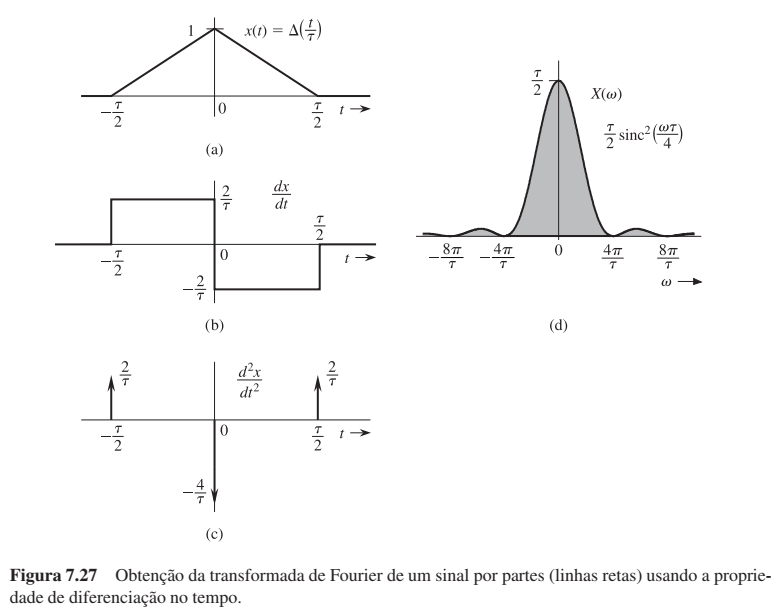